# **Assignment- 8: Logistic Regression**

**AIM:** Write a program to demonstrate the working of the Logistic Regression. Use

an appropriate data set and visualize the results.

**Import Required Libraries**

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from matplotlib.colors import ListedColormap
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print('Libraries imported')




Libraries imported


**Load Dataset**

In [42]:
data = {
    'Hours':[1,2,3,4,5,6,7,8,9,10],
    'Attendance':[50,55,60,65,70,75,80,85,90,95],
    'Result':['Fail','Fail','Fail','Fail','Pass','Pass','Pass','Pass','Pass','Pass']
}

df = pd.DataFrame(data)
df['Result'] = df['Result'].map({'Fail':0, 'Pass':1})

**Dataset Information**

In [44]:
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nClasses:', df['Result'].unique())   # updated target column name
df.describe()

Shape: (10, 3)

Columns: ['Hours', 'Attendance', 'Result']

Classes: [0 1]


,Hours,Attendance,Result
count,10.00000,10.000000,10.000000
mean,5.50000,72.500000,0.600000
std,3.02765,15.138252,0.516398
min,1.00000,50.000000,0.000000
25%,3.25000,61.250000,0.000000
50%,5.50000,72.500000,1.000000
75%,7.75000,83.750000,1.000000
max,10.00000,95.000000,1.000000


**Select Features and Target**

In [45]:
X = df[['Hours', 'Attendance']]   # your features
y = df['Result']                  # your target column
X.head()

,Hours,Attendance
0,1,50
1,2,55
2,3,60
3,4,65
4,5,70


**Split into Train and Test (70:30)**

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)
print('Training size:', X_train.shape)
print('Testing size:', X_test.shape)

Training size: (7, 2)
Testing size: (3, 2)


**Build Logistic Regression Mode**

In [47]:
logr = LogisticRegression()
logr.fit(X_train, y_train)
print('Model trained')

Model trained


In [48]:
logr = LogisticRegression()
logr.fit(X_train, y_train)

LogisticRegression()

**Predict Test Data and Compare Results**

In [49]:
y_pred = logr.predict(X_test)
results = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})
results['Status'] = results.apply(lambda r: 'Correct' if r.Actual == r.Predicted else 'Wrong', axis=1)
results.head(20)

,Actual,Predicted,Status
0,1,1,Correct
1,0,0,Correct
2,1,1,Correct


**Compute Accuracy and Classification Report**

In [50]:
print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('\nClassification Report:\n', classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
 [[1 0]
 [0 2]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



**Visualize Decision Boundary**

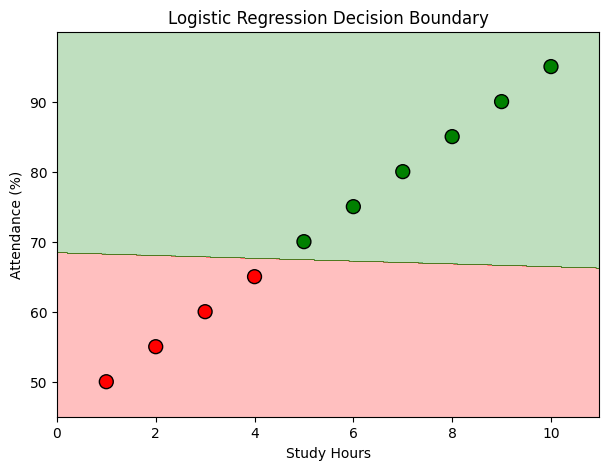

In [51]:
# 🔹 Create Mesh Grid
x_min, x_max = X.iloc[:,0].min()-1, X.iloc[:,0].max()+1
y_min, y_max = X.iloc[:,1].min()-5, X.iloc[:,1].max()+5

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# 🔹 Predict on grid
grid = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()],
                    columns=['Hours', 'Attendance'])

Z = logr.predict(grid)
Z = Z.reshape(xx.shape)

# 🔹 Color map
cmap = ListedColormap(['red', 'green'])

# 🔹 Plot
plt.figure(figsize=(7,5))

# Background decision boundary
plt.contourf(xx, yy, Z, alpha=0.25, cmap=cmap)

# 🔥 Visible dots (FIXED)
plt.scatter(X.iloc[:,0], X.iloc[:,1],
            c=y,
            cmap=cmap,
            s=100,              # bigger dots
            edgecolors='black', # outline
            zorder=3)           # bring to front

plt.xlabel('Study Hours')
plt.ylabel('Attendance (%)')
plt.title('Logistic Regression Decision Boundary')

plt.show()

**Predict for New Sample**

In [54]:
sample = pd.DataFrame([[4.8, 75]], columns=['Hours', 'Attendance'])

prediction = logr.predict(sample)

# Convert back to label
result = 'Pass' if prediction[0] == 1 else 'Fail'

print('Predicted class for sample:', result)

Predicted class for sample: Pass


**Conclusion:** The logistic regression model achieved strong accuracy, with most predictions matching the actual labels. The confusion matrix shows minimal misclassification, and the decision boundary visualization clearly separates the two classes. Overall, logistic regression proved effective for binary classification and gave an interpretable boundary between classes.